# Code Example for Linear Regression

In [63]:
import matplotlib.pyplot as plt 
import seaborn as sns 
import pandas as pd 
import numpy as np 

# for training model

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# For evaluation

from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

In [64]:
df = pd.read_csv("../../data/placement.csv")
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


Text(0, 0.5, 'Package(in Lpa)')

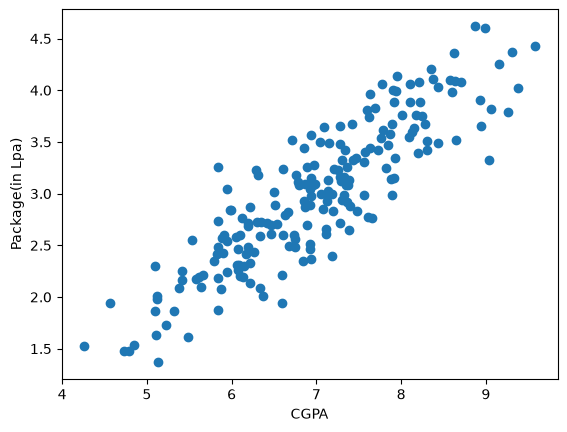

In [65]:
plt.scatter(df['cgpa'], df['package'])
plt.xlabel("CGPA")
plt.ylabel("Package(in Lpa)")

In [66]:
# Data is sort of linear

In [67]:
X = df.drop(columns = ['package'])
y = df['package']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [68]:
lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.57]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['cgpa']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.027
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [69]:
# lr.predict(X_test.iloc[0]) //Error
# lr.predict(X_test.iloc[0].reshape(1,1)) //Error
lr.predict(X_test.iloc[0].values.reshape(1,1))

c:\Users\aryan\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([2.78031348])

In [70]:
X_test

,cgpa
95,6.63
15,7.25
30,7.36
158,5.95
128,7.93
115,8.35
69,7.30
170,6.22
174,7.32
45,7.87


In [71]:
y_test

95     2.79
15     3.23
30     3.26
158    3.04
128    3.34
115    4.21
69     2.94
170    2.87
174    2.99
45     3.58
66     1.63
182    2.08
165    4.08
78     2.21
186    3.47
177    3.64
56     2.74
152    3.08
82     2.17
68     2.99
124    2.31
16     2.35
148    3.40
93     3.08
65     3.81
60     2.19
84     1.53
67     2.89
125    3.16
132    2.48
9      3.51
18     2.98
55     3.39
75     3.28
150    2.73
104    3.74
135    2.60
137    3.13
164    3.82
76     3.15
Name: package, dtype: float64

### Visualizing the best fit line formed by Linear Regression Model

Text(0, 0.5, 'Package(in Lpa)')

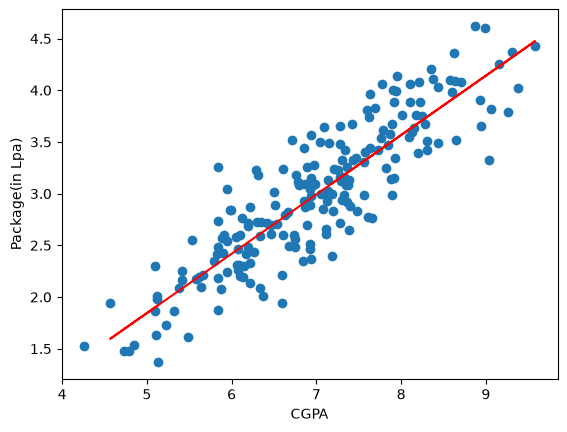

In [72]:
plt.scatter(df['cgpa'], df['package'])
plt.plot(X_train, lr.predict(X_train), color = 'red') # X_test can be used here, X_train is used just to see the line properly as it has more data
plt.xlabel("CGPA")
plt.ylabel("Package(in Lpa)")

In [73]:
lr.coef_ #Slope of best fit line

array([0.57425647])

In [74]:
lr.intercept_ #Intercept of best fit line

np.float64(-1.0270069374542108)

In [75]:
y_pred = lr.predict(X_test)

## NOTE -- Implementation of Simple LR from scratch is done in implementations from scratch repo --

## https://github.com/AryanGoyal17/Implementations-from-scratch

In [76]:
# done :)

# Applying Evaluation Metrics on trained Simple LR model

**y_test and y_pred(predictions stored in y_pred above NOTE) required**

In [77]:
print(f"MAE -- {mean_absolute_error(y_test, y_pred)}")
print(f"MSE -- {mean_squared_error(y_test, y_pred)}")
print(f"RMSE -- {root_mean_squared_error(y_test, y_pred)}")
print(f"R2 Score -- {r2_score(y_test, y_pred)}")

# Another method to find RMSE
print('\n')
print(f"RMSE(sqrt of MSE) -- {np.sqrt(mean_squared_error(y_test, y_pred))}")

MAE -- 0.23150985393278373
MSE -- 0.08417638361329656
RMSE -- 0.2901316659954521
R2 Score -- 0.7730984312051673


RMSE(sqrt of MSE) -- 0.2901316659954521


In [78]:
X_test.shape

(40, 1)

In [79]:
# Finding Adjusted r2 score
r2 = r2_score(y_test, y_pred)

adj_r2_score = 1 - ((1-r2)*(40 - 1) / (40-1-1))
print(f"Adjusted r2 Score -- {adj_r2_score}")

Adjusted r2 Score -- 0.7671273372895138


## Adding an irrelevant column to check if r2 increases and adjusted r2 decreases..

In [80]:
new_df1 = df.copy()
new_df1['random_feature'] = np.random.random(200)

new_df1 = new_df1[['cgpa','random_feature','package']]
new_df1.head()

,cgpa,random_feature,package
0,6.89,0.520697,3.26
1,5.12,0.189040,1.98
2,7.82,0.171303,3.25
3,7.42,0.469898,3.67
4,6.94,0.374996,3.57


Text(0, 0.5, 'Package(in lpa)')

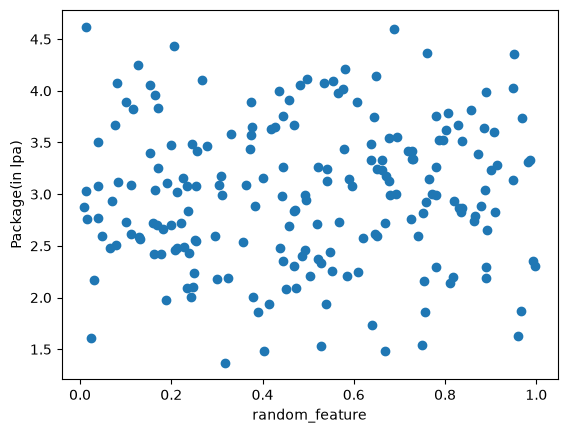

In [81]:
plt.scatter(new_df1['random_feature'],new_df1['package'])
plt.xlabel('random_feature')
plt.ylabel('Package(in lpa)')

In [82]:
X = new_df1.iloc[:,0:2]
y = new_df1.iloc[:,-1]

In [83]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [84]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

In [85]:
# R2 Score

print("R2 score",r2_score(y_test,y_pred))
r2 = r2_score(y_test,y_pred)

R2 score 0.7808154599389785


In [86]:
# Adjusted R2 score

adj_r2_score = 1 - ((1-r2)*(40 - 1) / (40-1-2))
print(f"Adjusted r2 Score -- {adj_r2_score}")

Adjusted r2 Score -- 0.7689676469627071


## Adding a relevant column to check if r2 increases and adjusted r2 also increases..

In [87]:
new_df2 = df.copy()

new_df2['iq'] = new_df2['package'] + (np.random.randint(-12,12,200)/10)

new_df2 = new_df2[['cgpa','iq','package']]
new_df2.sample(5)

,cgpa,iq,package
110,8.18,4.26,3.76
129,7.29,3.72,3.12
71,7.47,3.74,3.34
74,6.85,2.34,3.44
15,7.25,2.63,3.23


Text(0, 0.5, 'Package(in lpa)')

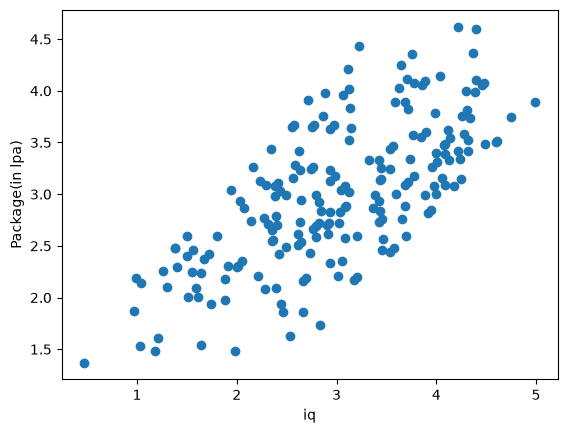

In [88]:
plt.scatter(new_df2['iq'],new_df2['package'])
plt.xlabel('iq')
plt.ylabel('Package(in lpa)')

In [89]:
np.random.randint(-100,100)

37

In [90]:
X = new_df2.iloc[:,0:2]
y = new_df2.iloc[:,-1]

In [91]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [92]:
lr = LinearRegression()
lr.fit(X_train,y_train)
y_pred = lr.predict(X_test)

In [93]:
# R2 Score

print("R2 score",r2_score(y_test,y_pred))
r2 = r2_score(y_test,y_pred)

R2 score 0.8137222382701726


In [94]:
#Adjusted r2 score --

1 - ((1-r2)*(40-1)/(40-1-2))

0.8036531700685603

In [96]:
# When we added an irrelevant column -- r2 increases but adj r2 almost same 
# When we added a relevant column -- r2 increases and adj r2 also increases

In [97]:
# done :)